# Chapter 61 — Rational Functions

> **Prerequisites:** ch060 (Polynomials), ch053 (Domain and Range)
>
> **You will learn:**
> - Identify vertical and horizontal asymptotes
> - Find and classify discontinuities
> - Plot rational functions with correct handling of asymptotes
> - Connect to partial fractions and computational stability
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **rational function** is a ratio of two polynomials: f(x) = p(x)/q(x), where q(x) ≠ 0.

The domain excludes all x where q(x) = 0.

Key features:
- **Vertical asymptotes:** at zeros of q(x) that are not also zeros of p(x). As x→a, f(x)→±∞
- **Removable discontinuities (holes):** at zeros shared by p and q — the function is undefined but has a limit
- **Horizontal asymptotes:** determined by comparing degrees of p and q as x→±∞
  - deg(p) < deg(q): y = 0
  - deg(p) = deg(q): y = leading coefficient ratio
  - deg(p) > deg(q): no horizontal asymptote (oblique or unbounded)

**Computational relevance:** Rational approximations of transcendental functions are used in high-performance math libraries. The Padé approximant is a rational function that approximates exp, sin, etc. more efficiently than polynomials alone.

---

## 2. Intuition & Mental Models

**Physical analogy:** A water tank filling at rate p(t) and draining at rate q(t). The net level is p/q. If q→0, the level explodes (vertical asymptote). If the rates equalize, the level stabilizes (horizontal asymptote).

**Computational analogy:** In numerical analysis, rational functions avoid the Runge phenomenon that plagues high-degree polynomial interpolation. They are better behaved at the boundaries of the domain.

---

## 3. Visualization

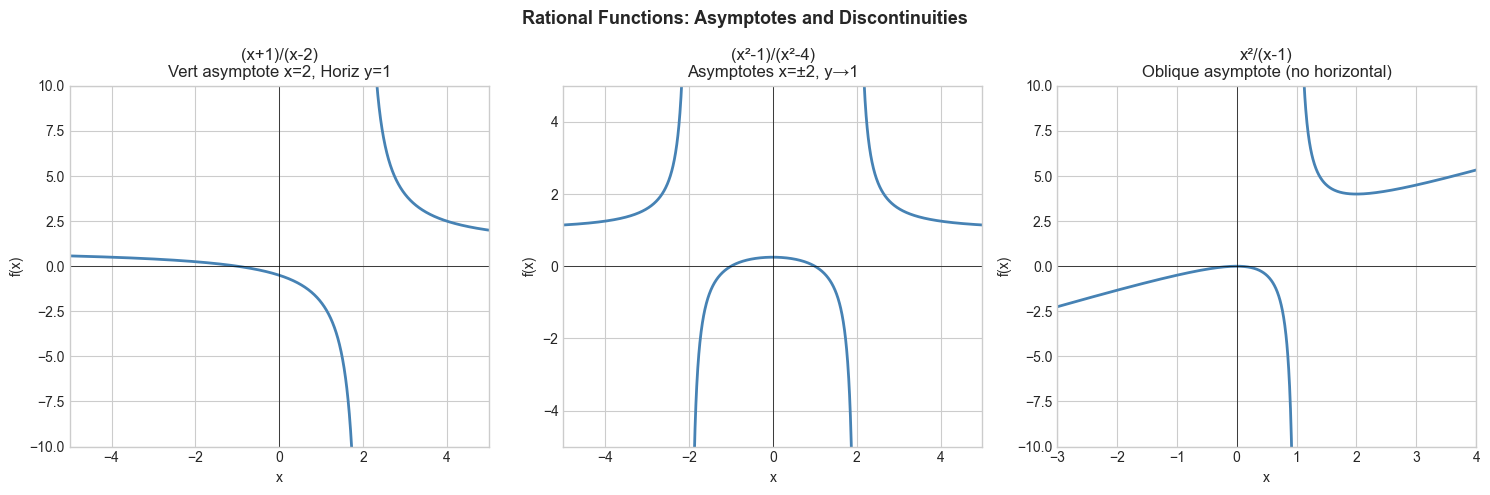

In [1]:
# --- Visualization: Rational function anatomy ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.linspace(-5, 5, 2000)

# 1. Simple rational with vertical and horizontal asymptote
def plot_rational(ax, p, q, xlim, ylim, title):
    with np.errstate(divide='ignore', invalid='ignore'):
        y = p(x) / q(x)
    y[np.abs(y) > 20] = np.nan
    ax.plot(x, y, color='steelblue', linewidth=2)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('f(x)')

plot_rational(axes[0], lambda x: x+1, lambda x: x-2, (-5,5), (-10,10),
              '(x+1)/(x-2)\nVert asymptote x=2, Horiz y=1')
plot_rational(axes[1], lambda x: x**2-1, lambda x: x**2-4, (-5,5), (-5,5),
              '(x²-1)/(x²-4)\nAsymptotes x=±2, y→1')
plot_rational(axes[2], lambda x: x**2, lambda x: x-1, (-3,4), (-10,10),
              'x²/(x-1)\nOblique asymptote (no horizontal)')

plt.suptitle('Rational Functions: Asymptotes and Discontinuities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Asymptote analysis:**

For f(x) = p(x)/q(x) with deg(p)=m, deg(q)=n:
- Vertical: at zeros of q that aren't zeros of p
- Horizontal: 
  - m < n → y = 0
  - m = n → y = (leading coeff of p)/(leading coeff of q)
  - m > n → no horizontal asymptote

**Limits at asymptotes:**
lim_{x→a⁺} p(x)/q(x) = +∞ or -∞ depending on signs

In [2]:
# --- Implementation: Asymptote finder ---
import numpy as np

def find_vertical_asymptotes(q_coeffs, p_coeffs=None, tol=1e-6):
    """Find approximate vertical asymptotes of p/q."""
    q_roots = np.roots(q_coeffs)
    real_roots = q_roots[np.abs(q_roots.imag) < tol].real
    if p_coeffs is None:
        return sorted(real_roots)
    # Remove removable discontinuities (shared roots)
    p_roots = np.roots(p_coeffs)
    p_real = p_roots[np.abs(p_roots.imag) < tol].real
    asymptotes = [r for r in real_roots
                  if not any(np.abs(r - pr) < tol for pr in p_real)]
    return sorted(asymptotes)

# f(x) = (x+1)(x-1) / (x-2)(x+3) = (x²-1)/(x²+x-6)
p = [1, 0, -1]       # x² - 1
q = [1, 1, -6]       # x² + x - 6  (roots at 2 and -3)
asym = find_vertical_asymptotes(q, p)
print("Vertical asymptotes:", asym)   # expected: [-3, 2]

# Horizontal asymptote
m, n = len(p)-1, len(q)-1
if m < n:   print("Horizontal: y = 0")
elif m == n: print(f"Horizontal: y = {p[0]}/{q[0]} = {p[0]/q[0]}")
else:        print("No horizontal asymptote")

Vertical asymptotes: [np.float64(-3.0), np.float64(2.0)]
Horizontal: y = 1/1 = 1.0


---

## 6. Experiments

**Experiment 1:** Plot f(x) = (x²-4)/(x-2). This has a removable discontinuity at x=2. Zoom in close to x=2 — what does Python plot? What does the limit approach?

**Experiment 2:** Compare 1/x, 1/x², 1/x³ near x=0. How does the behavior at the singularity change with the power?

---

## 7. Exercises

**Easy 1.** Find all asymptotes of f(x) = (2x+1)/(x-3). *(Expected: vertical x=3, horizontal y=2)*

**Easy 2.** Explain why f(x) = (x²-9)/(x-3) has a hole at x=3, not an asymptote.

**Medium 1.** Plot f(x) = 1/(1+e^(-x)) (the sigmoid). It looks like a rational function but isn't. Compare it to the Padé approximant of e^x: (1 + x/2) / (1 - x/2). Over what range are they similar?

**Medium 2.** Write a function that numerically computes the horizontal asymptote by evaluating f at x=10^6 and x=-10^6.

**Hard.** Implement partial fraction decomposition for f(x) = p(x)/q(x) where q has distinct roots. Use it to decompose 1/((x-1)(x-2)(x-3)) and verify the result by summing the fractions.

---

## 9. Chapter Summary & Connections

- Rational functions = p(x)/q(x); domain excludes zeros of q
- Vertical asymptotes where q=0 (and p≠0); removable holes where both are zero
- Horizontal asymptote determined by degree comparison
- Padé approximants use rational functions for efficient function approximation

**Forward connections:**
- Partial fractions reappear in integration of rational functions (ch223)
- Sigmoid function (ch064) is related to rational approximations to the logistic function